In [30]:
import pandas as pd
import numpy as np

In [31]:
# Load datasets
tags = pd.read_csv("tags.csv")
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

In [32]:
# Quick look at dataset
print(movies.head())



   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [33]:
# Check shape
print("Tags:", tags.shape)

Tags: (465564, 4)


DATA CLEANING PROCESS

In [34]:
#Step 1: Checking the Missing values

print("Movies missing values:\n", movies.isnull().sum())
print("----------------")
print("Ratings missing values:\n", ratings.isnull().sum())
print("----------------")
print("Tags missing values:\n", tags.isnull().sum())

Movies missing values:
 movieId    0
title      0
genres     0
dtype: int64
----------------
Ratings missing values:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
----------------
Tags missing values:
 userId        0
movieId       0
tag          16
timestamp     0
dtype: int64


In [35]:
#Step 2: Clean tags.csv by Dropping Null Rows

tags_cleaned = tags.dropna()

print("Before cleaning tags:", tags.shape)
print("After cleaning tags:", tags_cleaned.shape)

Before cleaning tags: (465564, 4)
After cleaning tags: (465548, 4)


In [36]:
#Step 3: Remove Unnecessary Columns (Timestamp)

ratings_cleaned = ratings.drop(columns=["timestamp"])

print(ratings_cleaned.head())

   userId  movieId  rating
0       1        2     3.5
1       1       29     3.5
2       1       32     3.5
3       1       47     3.5
4       1       50     3.5


DATA ANALYSIS

In [37]:
#Step 4: Merge Movies and Ratings

# Merge movies and ratings
merged_df = pd.merge(ratings_cleaned, movies, on="movieId")

print(merged_df.head())
print("Merged dataset shape:", merged_df.shape)

   userId  movieId  rating                                              title  \
0       1        2     3.5                                     Jumanji (1995)   
1       1       29     3.5  City of Lost Children, The (Cité des enfants p...   
2       1       32     3.5          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   
3       1       47     3.5                        Seven (a.k.a. Se7en) (1995)   
4       1       50     3.5                         Usual Suspects, The (1995)   

                                   genres  
0              Adventure|Children|Fantasy  
1  Adventure|Drama|Fantasy|Mystery|Sci-Fi  
2                 Mystery|Sci-Fi|Thriller  
3                        Mystery|Thriller  
4                  Crime|Mystery|Thriller  
Merged dataset shape: (1048575, 5)


In [38]:
#Step 5: Analyze Movies by Genre

# Split genres into list
merged_df["genre_list"] = merged_df["genres"].str.split("|")

# Explode so each genre gets its own row
genre_exploded = merged_df.explode("genre_list")

# Count movies per genre
genre_counts = genre_exploded["genre_list"].value_counts()

print(genre_counts)

genre_list
Drama                 461704
Comedy                395994
Action                293934
Thriller              278937
Adventure             230358
Romance               201209
Crime                 171866
Sci-Fi                166024
Fantasy               110815
Children               87101
Mystery                82157
Horror                 77518
Animation              59117
War                    54347
Musical                45788
IMAX                   25527
Western                22488
Documentary            12675
Film-Noir              11241
(no genres listed)         7
Name: count, dtype: int64


In [39]:
#Step 6: Identify High-Rated and Low-Rated Movies

#Compute average rating per movie

# Average rating per movie
avg_ratings = merged_df.groupby("title")["rating"].mean()

# Top 10 highest-rated movies
top_rated = avg_ratings.sort_values(ascending=False).head(10)

# Bottom 10 lowest-rated movies
low_rated = avg_ratings.sort_values(ascending=True).head(10)

print("Top 10 Highest Rated Movies:\n", top_rated)
print("\nTop 10 Lowest Rated Movies:\n", low_rated)

Top 10 Highest Rated Movies:
 title
FM (1978)                                                5.0
Thrashin' (1986)                                         5.0
Life and Nothing But (Vie et rien d'autre, La) (1989)    5.0
Earth (Tierra) (1996)                                    5.0
On a Clear Day (2005)                                    5.0
Damn the Defiant! (H.M.S. Defiant) (1962)                5.0
Miracle of Bern, The (Wunder von Bern, Das) (2003)       5.0
Burnt Money (Plata Quemada) (2000)                       5.0
Red's Dream (1987)                                       5.0
Cabeza de Vaca (1991)                                    5.0
Name: rating, dtype: float64

Top 10 Lowest Rated Movies:
 title
Zombie Lake (Lac des morts vivants, Le) (Zombies Lake) (Lake of the Living Dead, The) (1981)    0.5
Moment by Moment (1978)                                                                         0.5
Fairy, The (La fée) (2011)                                                               

In [40]:
#Step 7: Find Most-Rated Movies

# Count number of ratings per movie
rating_counts = merged_df["title"].value_counts()

# Top 10 most-rated movies
most_rated = rating_counts.head(10)

print("Top 10 Most Rated Movies:\n", most_rated)


Top 10 Most Rated Movies:
 title
Pulp Fiction (1994)                          3498
Forrest Gump (1994)                          3476
Silence of the Lambs, The (1991)             3247
Shawshank Redemption, The (1994)             3216
Jurassic Park (1993)                         3129
Star Wars: Episode IV - A New Hope (1977)    2874
Braveheart (1995)                            2799
Terminator 2: Judgment Day (1991)            2711
Matrix, The (1999)                           2705
Schindler's List (1993)                      2598
Name: count, dtype: int64


In [41]:
#Step 8: Extract Year from Movie Titles

# Extract year using regex
merged_df["year"] = merged_df["title"].str.extract(r"\((\d{4})\)")

# Convert year to numeric
merged_df["year"] = pd.to_numeric(merged_df["year"], errors="coerce")

print(merged_df[["title", "year"]].head())

                                               title    year
0                                     Jumanji (1995)  1995.0
1  City of Lost Children, The (Cité des enfants p...  1995.0
2          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)  1995.0
3                        Seven (a.k.a. Se7en) (1995)  1995.0
4                         Usual Suspects, The (1995)  1995.0


In [42]:
# Movies per year
movies_per_year = merged_df["year"].value_counts().sort_index()
print(movies_per_year.head(20))


year
1898.0      1
1900.0      1
1902.0     10
1903.0      2
1909.0      1
1910.0      1
1912.0      1
1913.0      1
1914.0      3
1915.0     19
1916.0     25
1917.0      8
1918.0      8
1919.0     23
1920.0    100
1921.0     75
1922.0    225
1923.0     41
1924.0     66
1925.0    325
Name: count, dtype: int64


SAMPLE INSIGHTS:

Drama and Comedy are the most common genres.

Some movies have very high ratings but few reviews (possible bias).

Popular movies are not always the highest-rated.

Movie production increased significantly after the 1990s.

Certain years have spikes in movie releases.

In [43]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


DATA VISUALIZATION


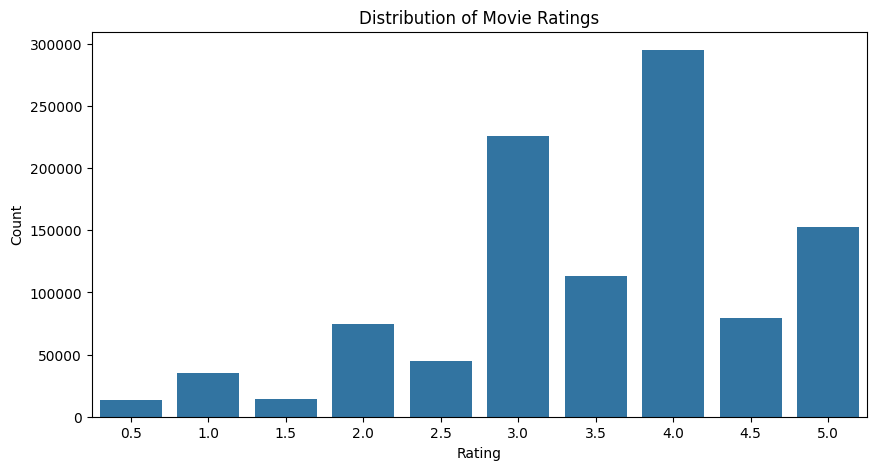

In [44]:
#Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of ratings
plt.figure(figsize=(10, 5))
sns.countplot(x="rating", data=merged_df)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


In [45]:
# Distribution of ratings with raw numbers
#No figures, just the numbers
rating_counts = merged_df["rating"].value_counts().sort_index()
rating_counts

rating
0.5     13232
1.0     35144
1.5     14029
2.0     74706
2.5     44791
3.0    226202
3.5    112926
4.0    295135
4.5     79848
5.0    152562
Name: count, dtype: int64

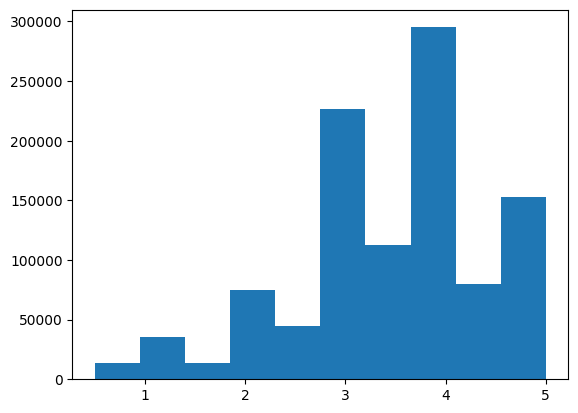

In [46]:
#Distributing of Ratings using histogram
#Matplotlib
plt.hist(merged_df["rating"], bins=10)
plt.show()

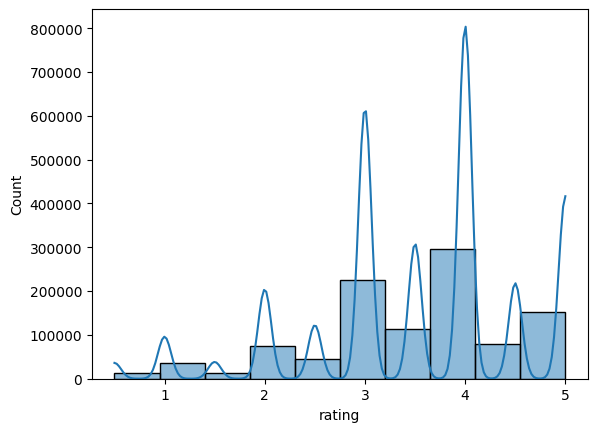

In [47]:
#Seaborn
sns.histplot(data=merged_df, x="rating", bins=10, kde=True)
plt.show()

In [48]:
# Most Rated Movies with raw numbers
most_rated_counts = merged_df["title"].value_counts().head(10)
most_rated_counts

title
Pulp Fiction (1994)                          3498
Forrest Gump (1994)                          3476
Silence of the Lambs, The (1991)             3247
Shawshank Redemption, The (1994)             3216
Jurassic Park (1993)                         3129
Star Wars: Episode IV - A New Hope (1977)    2874
Braveheart (1995)                            2799
Terminator 2: Judgment Day (1991)            2711
Matrix, The (1999)                           2705
Schindler's List (1993)                      2598
Name: count, dtype: int64

<Axes: xlabel='title'>

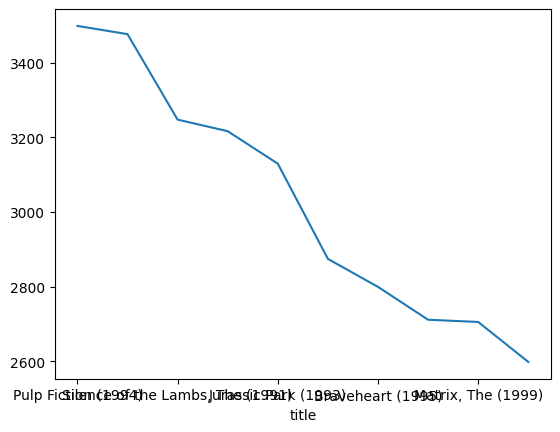

In [49]:
# Most Rated Movies using bar chart
most_rated_counts.plot(kind='line')

<Axes: xlabel='year'>

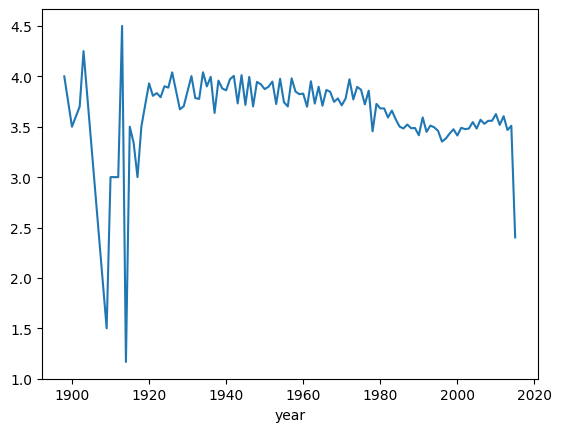

In [50]:
# Ratings over Time using Line graph
ratings_over_time = merged_df.groupby("year")["rating"].mean()
ratings_over_time.plot(kind='line')


Text(0.5, 1.0, 'Genre Distribution')

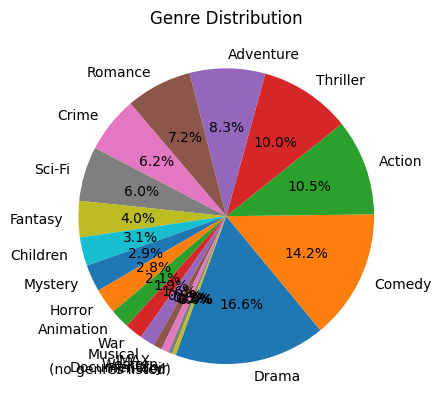

In [51]:
#Genre Analysis using Pie Chart
#Expand pie chart to show labels and percentages

genre_counts.plot(kind='pie', autopct='%1.1f%%', startangle=250)
plt.title("Genre Distribution")

Text(0.5, 1.0, 'Genre Distribution')

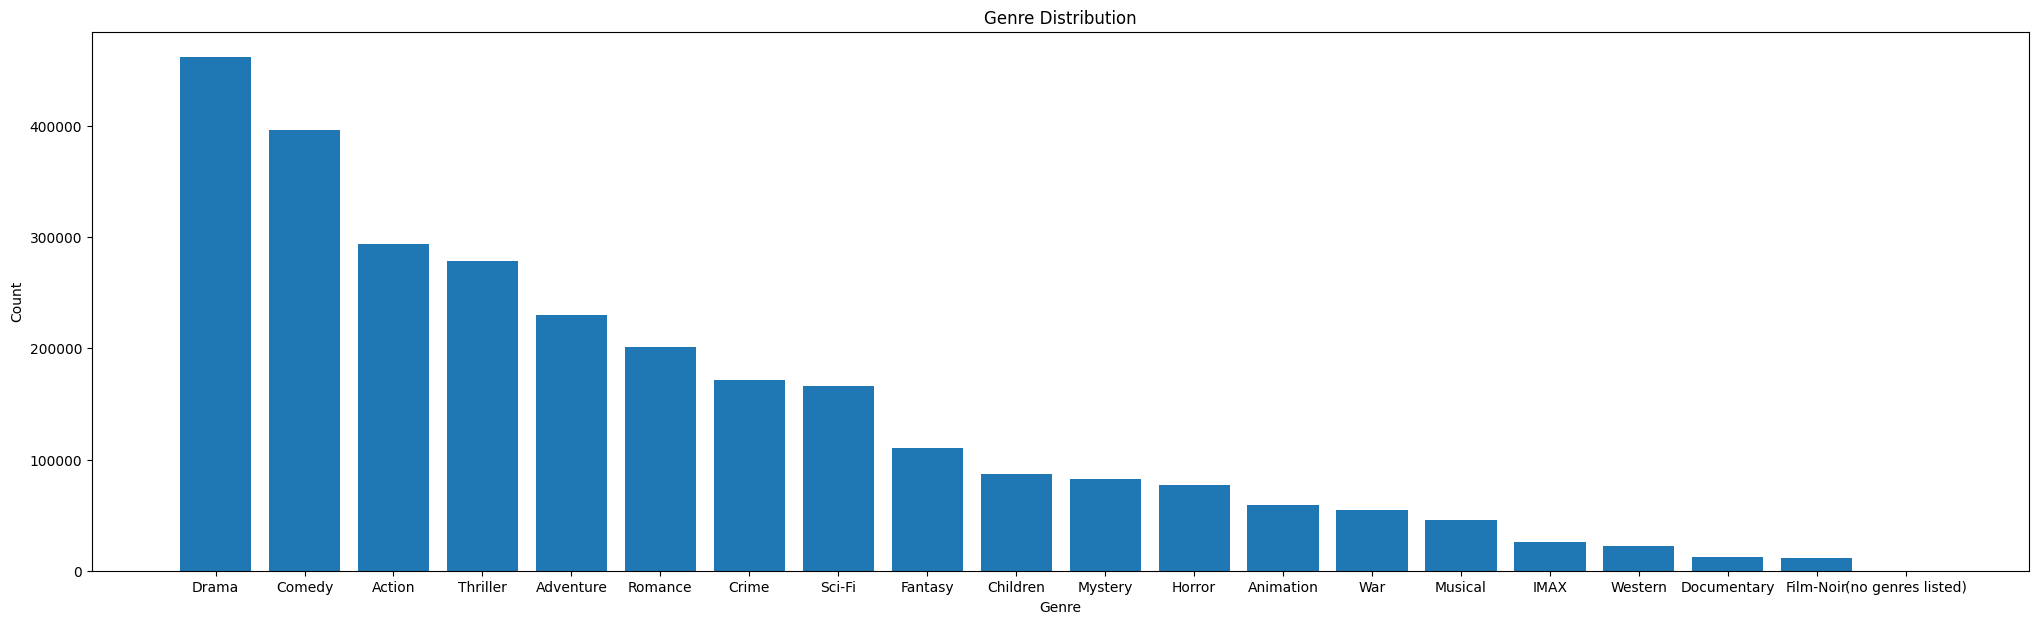

In [52]:
#Examples of Pure matplotlib
#Genre Aanalysis using matplotlib
plt.figure(figsize=(25, 7))
plt.bar(genre_counts.index, genre_counts.values)
plt.xlabel("Genre")
plt.ylabel("Count")
plt.title("Genre Distribution")

C:\Users\User\AppData\Local\Temp\ipykernel_40284\1546492054.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="Reds_d")


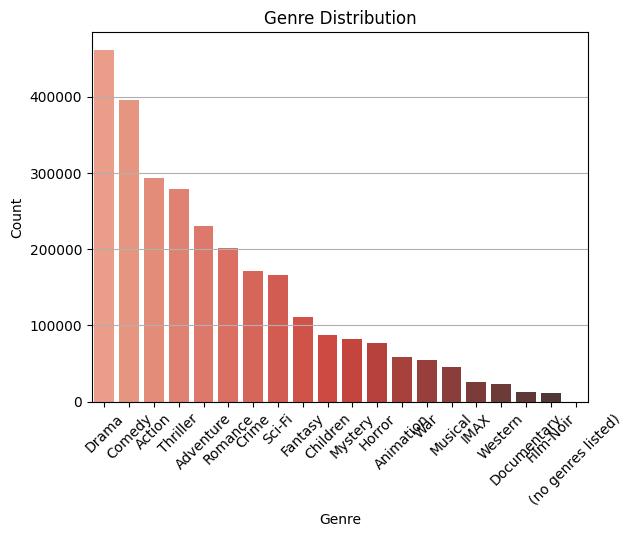

In [53]:
#Genre Distribution using Seaborn - expand to show labels and percentages 
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="Reds_d")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.title("Genre Distribution")
plt.xticks(rotation=45)
plt.grid(axis='y')

In [54]:
#Number of movies over the years
movies_per_year.plot(kind='scatter', x='year', y='count')
plt.title("Number of Movies Released Over the Years")

ValueError: plot kind scatter can only be used for data frames

In [ ]:
movies_per_year = (
    merged_df["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

movies_per_year.columns = ["year", "count"]

print(movies_per_year.head(20))

      year  count
0   1898.0      1
1   1900.0      1
2   1902.0     10
3   1903.0      2
4   1909.0      1
5   1910.0      1
6   1912.0      1
7   1913.0      1
8   1914.0      3
9   1915.0     19
10  1916.0     25
11  1917.0      8
12  1918.0      8
13  1919.0     23
14  1920.0    100
15  1921.0     75
16  1922.0    225
17  1923.0     41
18  1924.0     66
19  1925.0    325


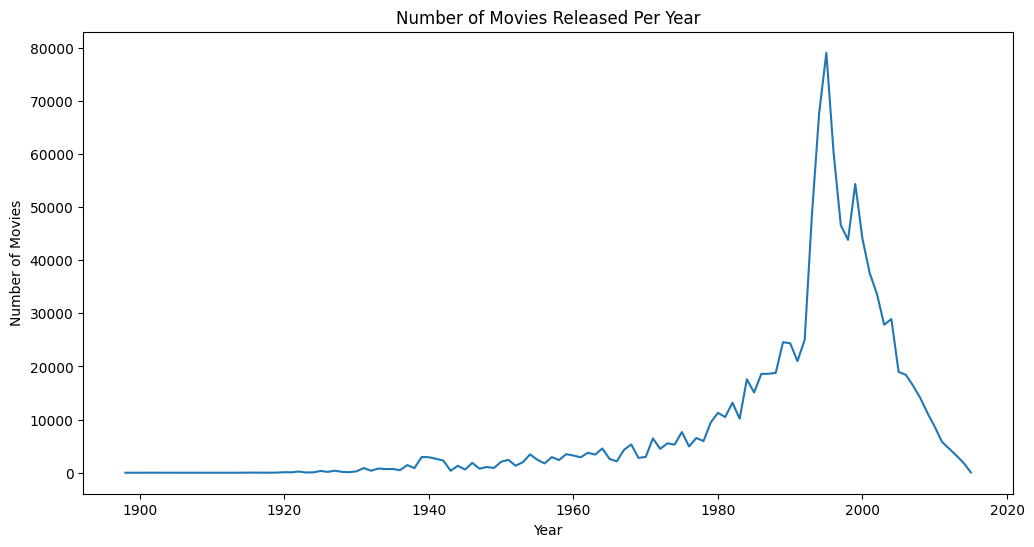

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(data=movies_per_year, x="year", y="count")

plt.title("Number of Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()